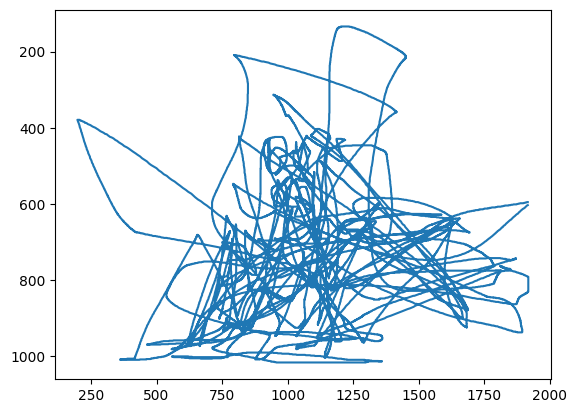

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import cv2

move = pd.read_csv("2026-04-22_131630_SlayTheSpire2.exe\mouse_move.csv")
click = pd.read_csv("2026-04-22_131630_SlayTheSpire2.exe\mouse_input.csv")
meta = pd.read_csv("2026-04-22_131630_SlayTheSpire2.exe\capture_metadata.csv")

# --- 時間変換 ---
move["timestamp"] = pd.to_datetime(move["timestamp"])
click["timestamp"] = pd.to_datetime(click["timestamp"])

# --- 区間指定 ---
start_time = move["timestamp"].min()

t_start = start_time + pd.Timedelta(seconds=40)
t_end   = start_time + pd.Timedelta(seconds=108)

# --- フィルタリング ---
move_range = move[
    (move["timestamp"] >= t_start) &
    (move["timestamp"] <= t_end)
]

click_range = click[
    (click["timestamp"] >= t_start) &
    (click["timestamp"] <= t_end)
]

plt.figure()
plt.plot(move["x"], move["y"])
plt.gca().invert_yaxis()  # 画面座標っぽくする
# plt.title("Mouse Trajectory")
plt.show()

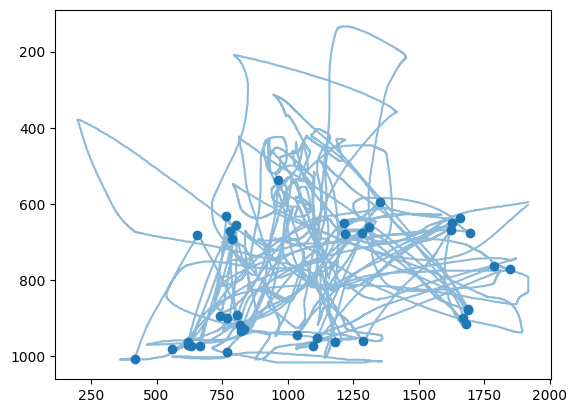

In [56]:
plt.figure()
plt.plot(move["x"], move["y"], alpha=0.5)

# mousedownだけ
clicks = click_range[click_range["event"] == "mousedown"]
plt.scatter(clicks["x"], clicks["y"])

plt.gca().invert_yaxis()
# plt.title("Trajectory + Clicks")
plt.show()

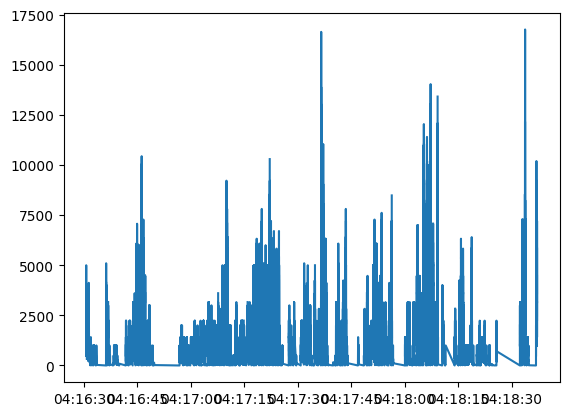

In [57]:
move["dt"] = move["timestamp"].diff().dt.total_seconds()
move["dx"] = move["x"].diff()
move["dy"] = move["y"].diff()

move["speed"] = (move["dx"]**2 + move["dy"]**2)**0.5 / move["dt"]

plt.figure()
plt.plot(move["timestamp"], move["speed"])
# plt.title("Mouse Speed Over Time")
plt.show()

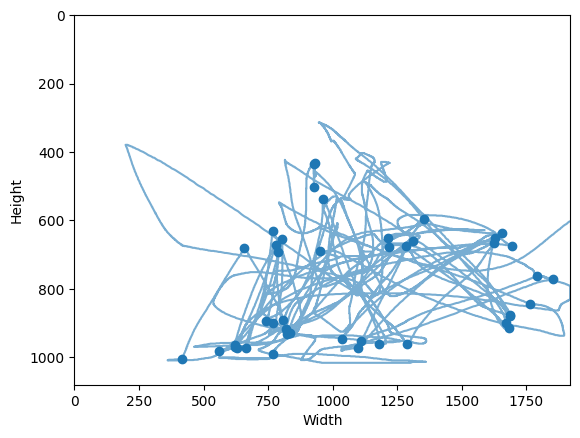

In [58]:
# 時間変換
move["timestamp"] = pd.to_datetime(move["timestamp"])
click["timestamp"] = pd.to_datetime(click["timestamp"])
meta["utc_timestamp"] = pd.to_datetime(meta["utc_timestamp"])

# 基準時間（開始から40秒後）
start_time = move["timestamp"].min()
threshold = start_time + pd.Timedelta(seconds=40)

# フィルタリング
move_40 = move[move["timestamp"] >= threshold]
click_40 = click[click["timestamp"] >= threshold]

# 画面サイズ（metadataから取得）
width = meta["content_width"].iloc[0]
height = meta["content_height"].iloc[0]

# 描画
plt.figure()

# 軌跡
plt.plot(move_40["x"], move_40["y"], alpha=0.6)

# クリック（mousedownだけ）
clicks = click_40[click_40["event"] == "mousedown"]
plt.scatter(clicks["x"], clicks["y"])

# 軸設定（画面座標）
plt.xlim(0, width)
plt.ylim(height, 0)  # 上が0にする（重要）

plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

In [59]:
import cv2

cap = cv2.VideoCapture("2026-04-22_131630_SlayTheSpire2.exe\capture.mp4")

# 取りたい秒数
target_sec = 43

# fps取得
fps = cap.get(cv2.CAP_PROP_FPS)

# フレーム番号に変換
frame_number = int(fps * target_sec)

# フレーム位置を指定
cap.set(cv2.CAP_PROP_POS_MSEC, 43500)  # 40秒 = 40000ms
ret, frame = cap.read()

ret, frame = cap.read()

if ret:
    cv2.imwrite("screenshot_43s.png", frame)

cap.release()

<Figure size 1000x600 with 0 Axes>

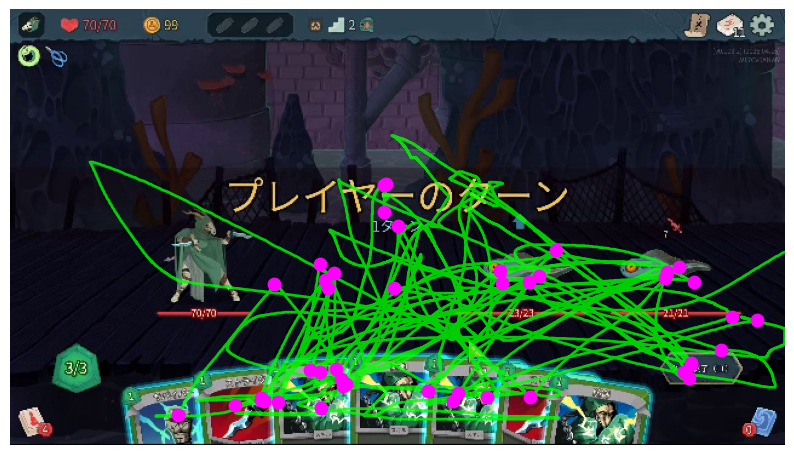

In [62]:
# OpenCV(BGR) → matplotlib(RGB)
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


# --- 画面サイズ ---
width = meta["content_width"].iloc[0]
height = meta["content_height"].iloc[0]

# --- 描画 ---
plt.figure(figsize=(10, 6))

plt.figure(figsize=(10, 6))

# 背景
plt.imshow(frame, extent=[0, width, height, 0])

# 軌跡（奥）
plt.plot(
    move_40["x"], move_40["y"],
    color="#00FF00",
    linewidth=2,
    alpha=0.8,
    zorder=2
)

# クリック（手前）
plt.scatter(
    clicks["x"], clicks["y"],
    color="#FF00FF",
    s=80,
    zorder=3
)

plt.axis("off")

# plt.xlim(0, width)
# plt.ylim(height, 0)

# plt.xlabel("Width")
# plt.ylabel("Height")
# # plt.title("Mouse Trajectory + Clicks (after 40s)")

plt.show()